# Student Academic Insights Dashboard

This project analyzes student academic behavior using study habits, attendance, sleep patterns, and assignment completion. The goal is to explore patterns in student performance and build a machine learning model to predict grade categories.

## Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Load Dataset


In [2]:
df = pd.read_csv("student_data.csv")


## Dataset Overview


In [3]:
# Start index from 1 instead of 0
df.index = df.index + 1

# Display dataset
df.head()

,Study_Hours,Attendance,Sleep_Hours,Assignments_Completed,Grade
1,2,61,7,6,C
2,4,68,5,4,C
3,10,87,5,3,A
4,2,73,6,3,C
5,9,72,9,9,A


## Data Cleaning


In [4]:
df.isnull().sum()
df = df.dropna()


## Dataset Structure

In [5]:
info_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values
})

info_table.index = info_table.index + 1
info_table

,Column Name,Data Type,Non-Null Count
1,Study_Hours,int64,120
2,Attendance,int64,120
3,Sleep_Hours,int64,120
4,Assignments_Completed,int64,120
5,Grade,object,120


## Statistical Summary


In [6]:
df.describe()

,Study_Hours,Attendance,Sleep_Hours,Assignments_Completed
count,120.000000,120.000000,120.000000,120.000000
mean,5.525000,79.716667,6.858333,6.216667
std,2.947617,11.527959,1.421893,2.142736
min,1.000000,60.000000,5.000000,3.000000
25%,3.000000,69.750000,6.000000,4.000000
50%,5.000000,79.500000,7.000000,6.000000
75%,8.000000,89.000000,8.000000,8.000000
max,10.000000,100.000000,9.000000,10.000000


## Correlation Analysis

In [8]:
df.corr(numeric_only=True).round(2)

,Study_Hours,Attendance,Sleep_Hours,Assignments_Completed
Study_Hours,1.00,0.08,-0.01,0.05
Attendance,0.08,1.00,0.11,-0.09
Sleep_Hours,-0.01,0.11,1.00,0.02
Assignments_Completed,0.05,-0.09,0.02,1.00


## Study Hours vs Attendance


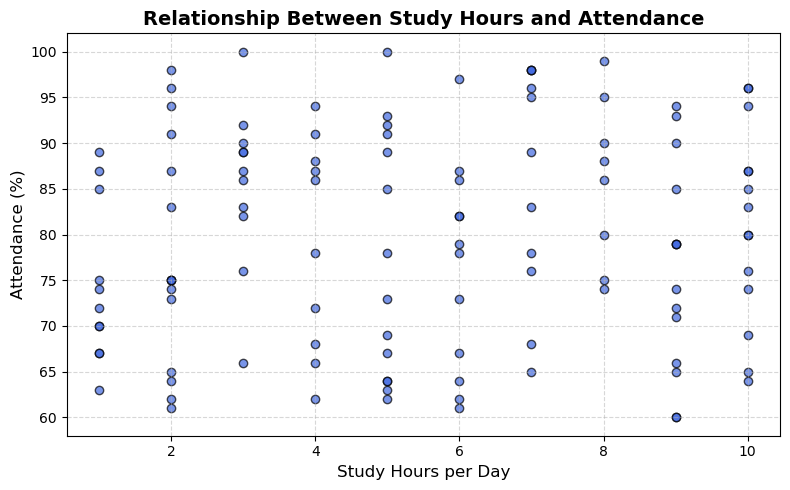

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Study_Hours'],
    df['Attendance'],
    color='royalblue',
    edgecolor='black',
    alpha=0.7
)

plt.title("Relationship Between Study Hours and Attendance", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours per Day", fontsize=12)
plt.ylabel("Attendance (%)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Attendance Distribution

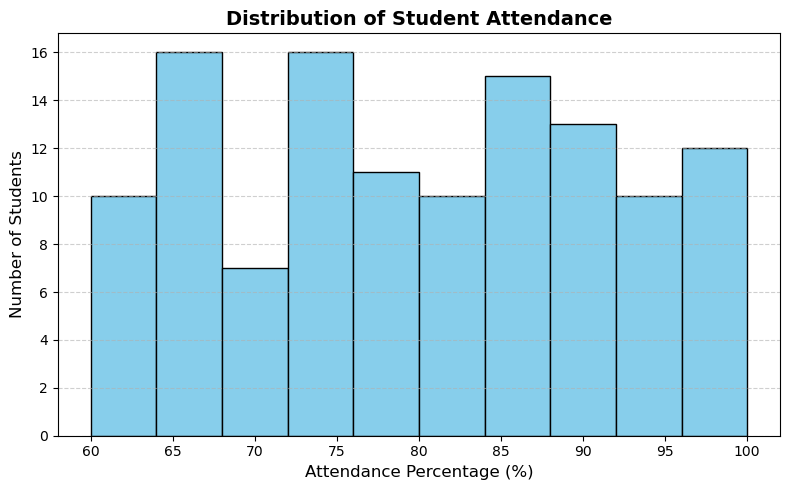

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Attendance'],
    bins=10,
    color='skyblue',
    edgecolor='black'
)

plt.title("Distribution of Student Attendance", fontsize=14, fontweight='bold')
plt.xlabel("Attendance Percentage (%)", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

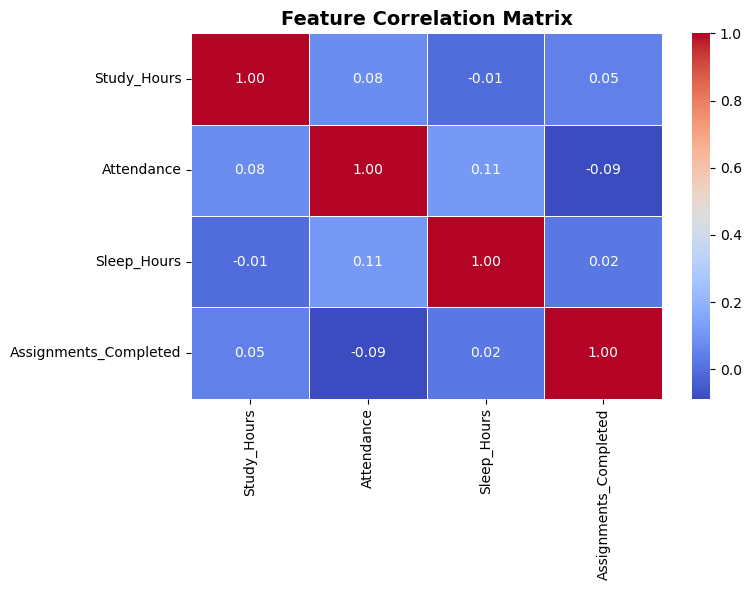

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Selection

In [12]:
X = df[['Study_Hours','Attendance','Sleep_Hours','Assignments_Completed']]
y = df['Grade']

## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

## Model Training

In [14]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Model Prediction

In [15]:
predictions = model.predict(X_test)

## Model Accuracy

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8333333333333334


### Performance Score Calculation


In [22]:
# Normalize features to 0–100 scale
study_score = (df['Study_Hours'] / df['Study_Hours'].max()) * 100
attendance_score = df['Attendance']  # already 0–100
assign_score = (df['Assignments_Completed'] / df['Assignments_Completed'].max()) * 100

# Weighted performance score
df['Performance_Score'] = (
    0.4 * study_score +
    0.4 * attendance_score +
    0.2 * assign_score
).round(2)

### Grade Classification

In [23]:
def assign_grade(score):
    if score >= 85:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 55:
        return 'C'
    else:
        return 'D'

df['Grade'] = df['Performance_Score'].apply(assign_grade)

### Grade Distribution Table

In [24]:
grade_table = grade_counts.reset_index()

grade_table.columns = ['Grade Category','Number of Students']

# Start index from 1 instead of 0
grade_table.index = grade_table.index + 1



grade_table

,Grade Category,Number of Students
1,A,64
2,B,30
3,C,22
4,D,4


## Interactive Insights Dashboard

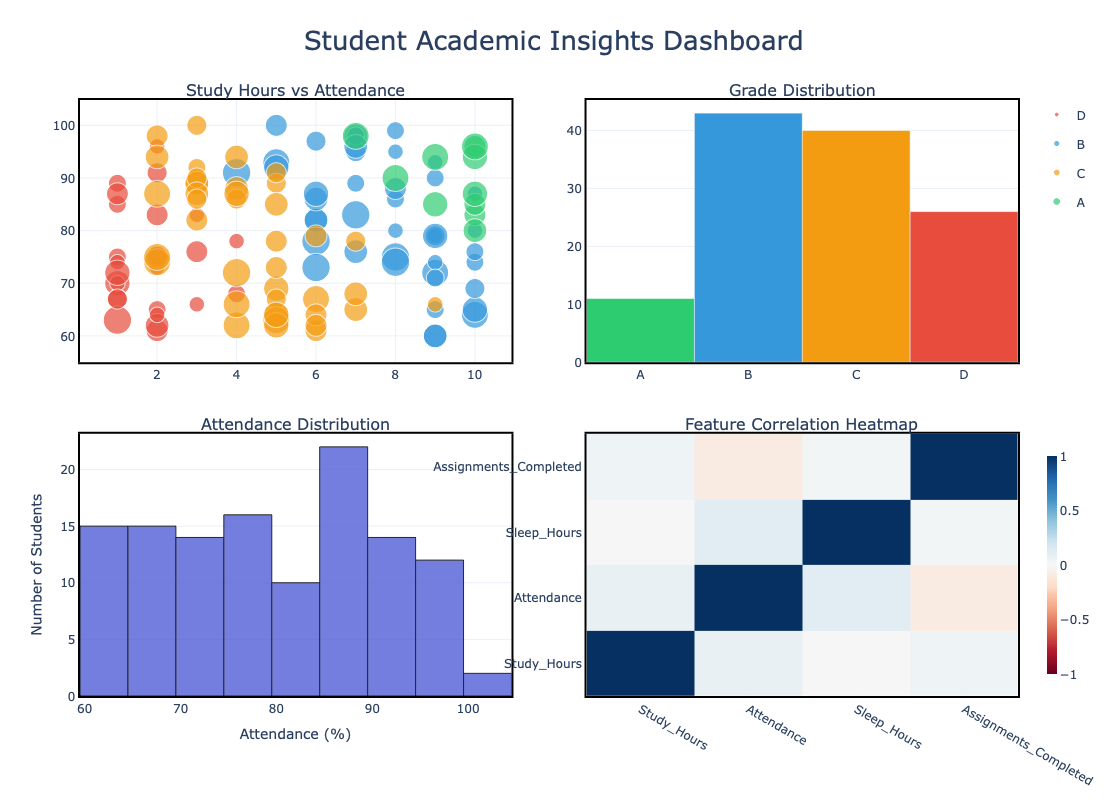

In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Prepare data
grade_counts = df['Grade'].value_counts().reindex(['A','B','C','D'])
corr = df[['Study_Hours','Attendance','Sleep_Hours','Assignments_Completed']].corr()

# Create dashboard layout
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Study Hours vs Attendance",
        "Grade Distribution",
        "Attendance Distribution",
        "Feature Correlation Heatmap"
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

# 1️⃣ Scatter Plot
scatter = px.scatter(
    df,
    x="Study_Hours",
    y="Attendance",
    color="Grade",
    size="Assignments_Completed",
    hover_data=["Sleep_Hours"],
    color_discrete_map={
        "A":"#2ecc71",
        "B":"#3498db",
        "C":"#f39c12",
        "D":"#e74c3c"
    }
)

for trace in scatter.data:
    fig.add_trace(trace, row=1, col=1)

# 2️⃣ Grade Distribution
fig.add_trace(
    go.Bar(
        x=grade_counts.index,
        y=grade_counts.values,
        marker_color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
        showlegend=False
    ),
    row=1,
    col=2
)

# 3️⃣ Attendance Histogram
fig.add_trace(
    go.Histogram(
        x=df["Attendance"],
        nbinsx=12,
        marker=dict(
            color="#5A67D8",
            line=dict(color="black", width=1)
        ),
        opacity=0.85,
        showlegend=False
    ),
    row=2,
    col=1
)

fig.update_xaxes(
    title_text="Attendance (%)",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="Number of Students",
    row=2,
    col=1
)

# 4️⃣ Heatmap (color scale kept inside panel)
fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale="RdBu",
        zmin=-1,
        zmax=1,
        colorbar=dict(
            thickness=10,
            len=0.4,
            y=0.22
        )
    ),
    row=2,
    col=2
)

# Layout
fig.update_layout(
    title={
        "text":"Student Academic Insights Dashboard",
        "x":0.5,
        "font":{"size":26}
    },
    template="plotly_white",
    height=800,
    width=1100
)

# Add borders around each subplot
fig.update_xaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig.update_yaxes(showline=True, linewidth=2, linecolor='black', mirror=True)

fig.show()

### Conclusion

This project analyzed student academic data to evaluate performance using study hours, attendance, and assignment completion. A performance score and grade categories were created to understand student outcomes. The dashboard visualizations summarize these insights and demonstrate how data analysis can support better academic understanding and decision-making.